# Week 4 - Univariate Analysis, part 2

# 1. Lesson - None

# 2. Weekly graph question

Below are a histogram and boxplot representation of the same data. A pharmacy is keeping a record of the prices of the drugs that it sells, and an administrator wants to know how much the more expensive drugs tend to cost, in the context of the other prices.

Please write a short explanation of the pros and cons of these two representations. Which would you choose? How would you modify the formatting, if at all, to make it more visually interesting, clear, or informative?

In [109]:
import numpy as np
import pandas as pd

np.random.seed(0)
num_data = 100
data = np.exp(np.random.uniform(size = num_data) * 4)
df = pd.DataFrame(data.T, columns = ["data"])

The 75th percentile is: data    15.457656
Name: 0.75, dtype: float64


<Axes: ylabel='Frequency'>

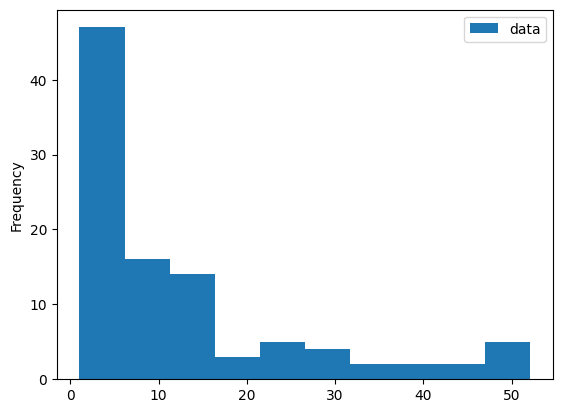

In [110]:
print("The 75th percentile is:", df.quantile(q = 0.75))
df.plot.hist()

<Axes: >

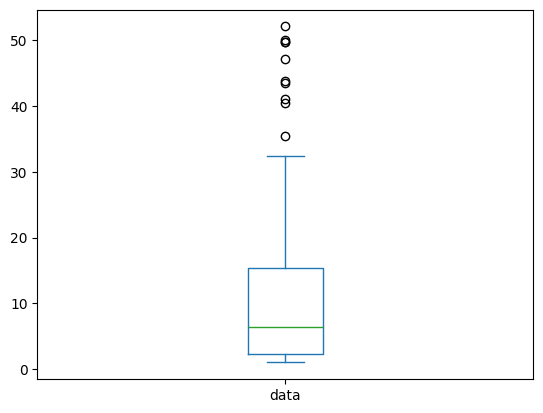

In [111]:
df.plot.box()

HISTOGRAM

PROS: The histogram shows the full distribution shape, reveals the skews (right skew), shows how prices cluster and lets you see frequency patterns.

CONS: It's harder to extract exact summary values like median or quartiles, it's sensitive to the number of bins and in the case of outliers it's more sensitive.

BOXPLOT

PROS: The boxplot summarizes the distribution in a compact way. You get a clear idea of exact summary values like median, 25th and 75th percentiles and outliers.

CONS: The boxplot hides the shape of the distribution, it doesn't show whether values cluster and it doesn't show density patterns.

If I had to choose one representation for the administrator’s question, I would select the histogram because it better communicates the overall distribution and the extent of the right tail. However, the most informative approach would be to consider both together. I would use the histogram to show distribution shape and skewness, and the boxplot to summarize key statistics and highlight outliers. To improve the histogram of drug prices, several changes would make it clearer and more informative. First, applying a logarithmic scale to the x-axis would help address the extreme right skew of the data, preventing the few very expensive drugs from stretching the axis and compressing the majority of lower-priced drugs. Increasing the number of bins moderately would create a smoother, more detailed curve, allowing the distribution of prices to be seen more clearly. Adding vertical reference lines to mark key statistics, such as the median and the 75th percentile, would provide context and make it easier to interpret how the more expensive drugs compare to the rest of the data. I would also add more detailed axis labels like "Drug Prices" for the x-axis and include units. Overall, these modifications would help the histogram communicate both the distribution shape and the relative position of higher-priced drugs in a more readable and visually engaging way.

# 3. Homework - working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

### Here are some types of analysis you can do:

- Draw histograms and histogram variants for each feature or column.  (Swarm plot, kde plot, violin plot).

- Draw grouped histograms.  For instance, if you have tree heights for both maple and oak trees, you could draw histograms for both.

- Draw a bar plot to indicate total counts of each categorical variable in a given column.

- Find means, medians, and modes.

### Conclusions:

- Explain what conclusions you would draw from this analysis: are the data what you expect?  Are the data likely to be usable?  If they are not useable, find some new data!

- What is the overall shape of the distribution?  Is it normal, skewed, bimodal, uniform, etc.?

- Are there any outliers present?  (Data points that are far from the others.)

- If there are multiple related histograms, how does the distribution change across different groups?

- What are the minimum and maximum values represented in each histogram?

- How do bin sizes affect the histogram?  Does changing the bin width reveal different patterns in the data?

- Does the distribution appear normal, or does it have a different distribution?

In [112]:
ecommerce = pd.read_csv("Ecommerce2020.csv", encoding="latin-1")
ecommerce

,Order Date,Row ID,Order ID,Ship Mode,Customer ID,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,01-01-20,849,CA-2017-107503,Standard Class,GA-14725,Consumer,United States,Lorain,Ohio,44052,East,FUR-FU-10003878,Furniture,Furnishings,"Linden 10"" Round Wall Clock, Black",48.896,4,0.2,8.5568
1,01-01-20,4010,CA-2017-144463,Standard Class,SC-20725,Consumer,United States,Los Angeles,California,90036,West,FUR-FU-10001215,Furniture,Furnishings,"Howard Miller 11-1/2"" Diameter Brentwood Wall ...",474.430,11,0.0,199.2606
2,01-01-20,6683,CA-2017-154466,First Class,DP-13390,Home Office,United States,Franklin,Wisconsin,53132,Central,OFF-BI-10002012,Office Supplies,Binders,Wilson Jones Easy Flow II Sheet Lifters,3.600,2,0.0,1.7280
3,01-01-20,8070,CA-2017-151750,Standard Class,JM-15250,Consumer,United States,Huntsville,Texas,77340,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,454.560,5,0.2,-107.9580
4,01-01-20,8071,CA-2017-151750,Standard Class,JM-15250,Consumer,United States,Huntsville,Texas,77340,Central,FUR-FU-10002116,Furniture,Furnishings,"Tenex Carpeted, Granite-Look or Clear Contempo...",141.420,5,0.6,-187.3815
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3307,30-12-20,908,CA-2017-143259,Standard Class,PO-18865,Consumer,United States,New York City,New York,10009,East,TEC-PH-10004774,Technology,Phones,Gear Head AU3700S Headset,90.930,7,0.0,2.7279
3308,30-12-20,909,CA-2017-143259,Standard Class,PO-18865,Consumer,United States,New York City,New York,10009,East,OFF-BI-10003684,Office Supplies,Binders,Wilson Jones Legal Size Ring Binders,52.776,3,0.2,19.7910
3309,30-12-20,1297,CA-2017-115427,Standard Class,EB-13975,Corporate,United States,Fairfield,California,94533,West,OFF-BI-10002103,Office Supplies,Binders,"Cardinal Slant-D Ring Binder, Heavy Gauge Vinyl",13.904,2,0.2,4.5188
3310,30-12-20,1298,CA-2017-115427,Standard Class,EB-13975,Corporate,United States,Fairfield,California,94533,West,OFF-BI-10004632,Office Supplies,Binders,GBC Binding covers,20.720,2,0.2,6.4750


In [113]:
obj_cols = ecommerce.select_dtypes(include='object')

/var/folders/49/kcjnh__d7ks4bl39vfsg1w940000gn/T/ipykernel_99718/2823163272.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  obj_cols = ecommerce.select_dtypes(include='object')


In [114]:
num_cols = ecommerce.select_dtypes(include = 'integer')

In [115]:
float_cols = ecommerce.select_dtypes(include = 'float')

Text(0.5, 1.0, 'KDE of Profit')

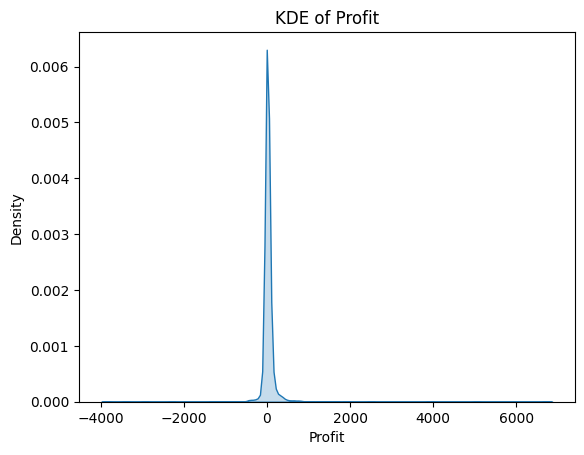

In [116]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.kdeplot(ecommerce['Profit'], fill=True)
plt.title("KDE of Profit")

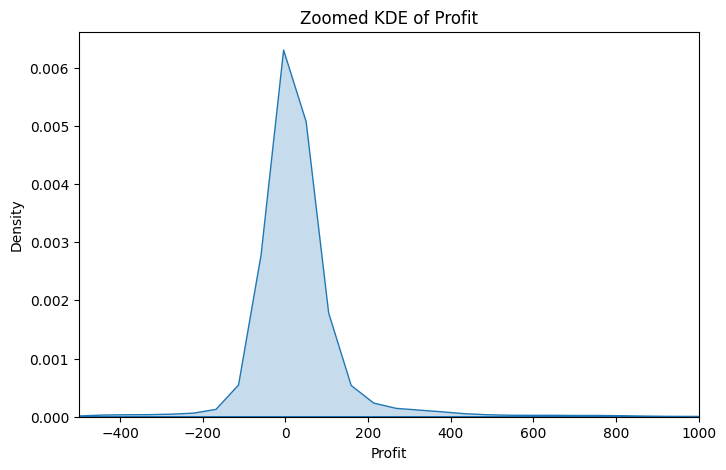

In [117]:
plt.figure(figsize=(8,5))
sns.kdeplot(ecommerce['Profit'], fill=True)

plt.xlim(-500, 1000)
plt.title("Zoomed KDE of Profit")
plt.show()

In this zoomed in version of the previous KDE plot we can ignore the less significant values whose density hovers around 0 and more clearly see where the profit is more heavily concentrated. The profit for the whole dataset is most often $0.00 but fluctuates in -$200 and $200 range with a normal distribution. 

(0.0, 5.0)

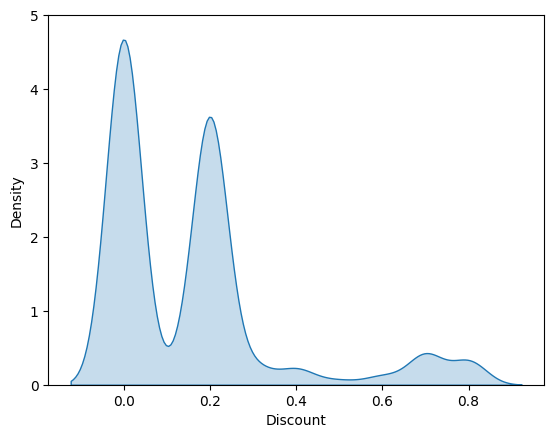

In [118]:
sns.kdeplot(ecommerce['Discount'], fill=True)
plt.ylim(0, 5)

Here we can see a bimodal distribution where the most frequent discounts applied to orders are 0% and 20%.

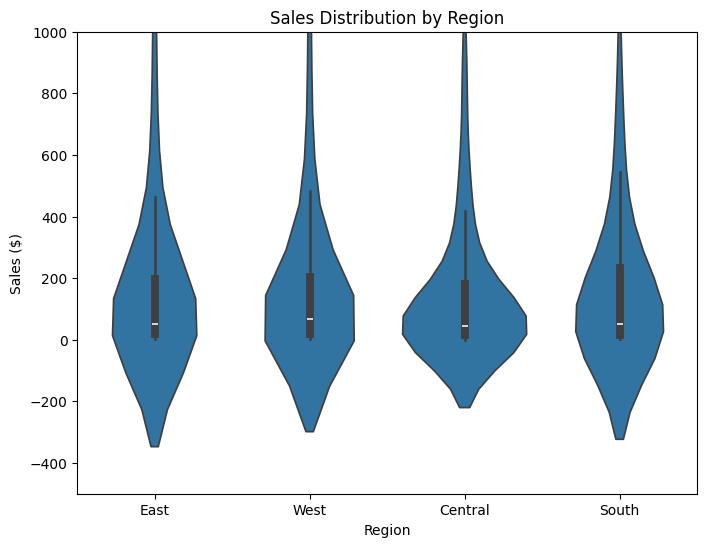

In [119]:

plt.figure(figsize=(8,6))
sns.violinplot(x='Region', y='Sales', data=ecommerce)
plt.ylim(-500, 1000)
plt.title('Sales Distribution by Region')
plt.ylabel('Sales ($)')
plt.show()

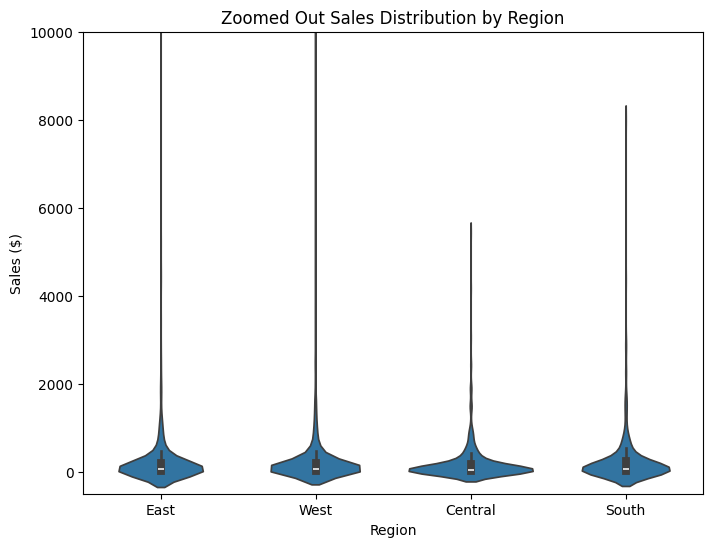

In [120]:
plt.figure(figsize=(8,6))
sns.violinplot(x='Region', y='Sales', data=ecommerce)
plt.ylim(-500, 10000)
plt.title('Zoomed Out Sales Distribution by Region')
plt.ylabel('Sales ($)')
plt.show()

The violin plot above comparing the distribution of sale numbers across regions shows the data is unimodal for all 4. It's clear that the central United States has the highest concentration of data points around the $0 and $100 marks compared to the other three regions that are narrower indicating fewer values and less total sales. The negative values seen could indicate returns and refunds. Other than the central USA, the shapes are pretty similar indicating an evenly distributed sales contribution across the East, West and South. I included the zoomed out version of the violin plot to show the pretty significant range of the dataset and the outliers that are present.

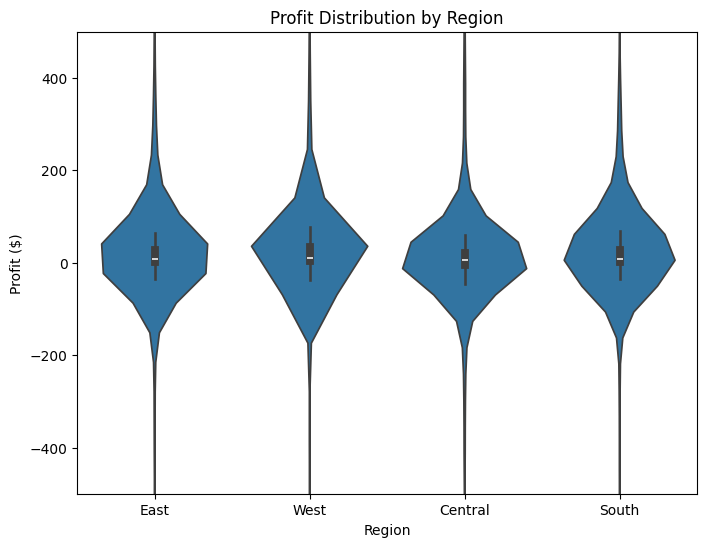

In [121]:
plt.figure(figsize=(8,6))
sns.violinplot(x='Region', y='Profit', data=ecommerce)
plt.ylim(-500, 500)
plt.title('Profit Distribution by Region')
plt.ylabel('Profit ($)')
plt.show()

In this example we can see the the distribution of the profit across regions and (even though there are still outliers) the distriution is not as wide and most of the density falls between the -$200 and $200 range. There is a slight variation in the shapes and we can still see the slightly higher density around $0 for the central USA but the shape of all four is pretty uniform with a normal distribution.

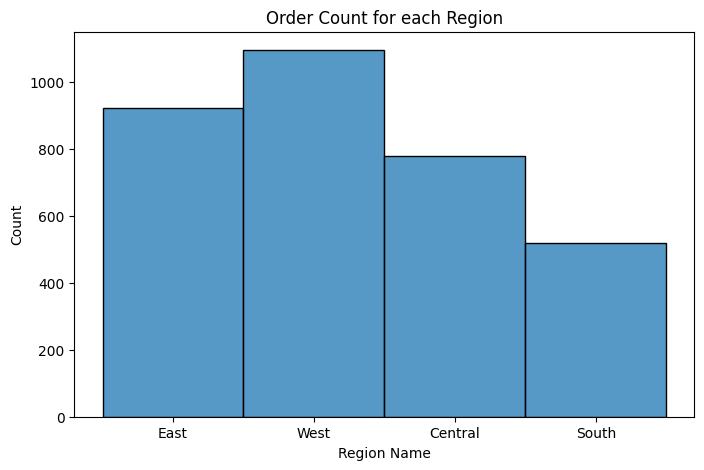

In [122]:
plt.figure(figsize=(8,5))
sns.histplot(ecommerce['Region'], bins=10)
plt.title("Order Count for each Region")
plt.xlabel("Region Name")
plt.ylabel("Count")
plt.show()

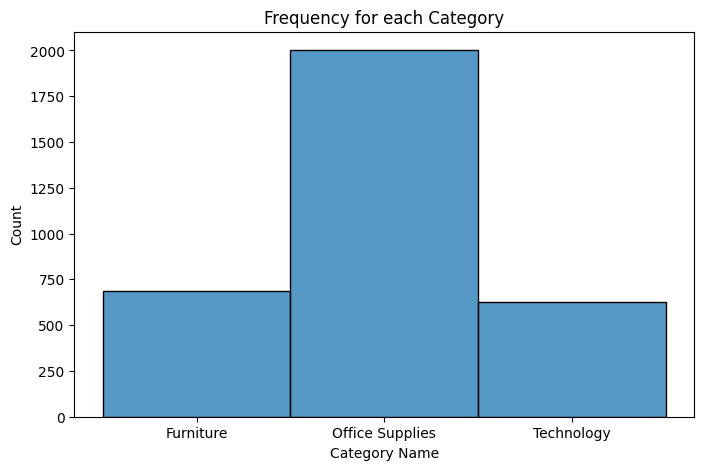

In [123]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.histplot(ecommerce['Category'], bins=10)
plt.title("Frequency for each Category")
plt.xlabel("Category Name")
plt.ylabel("Count")
plt.show()

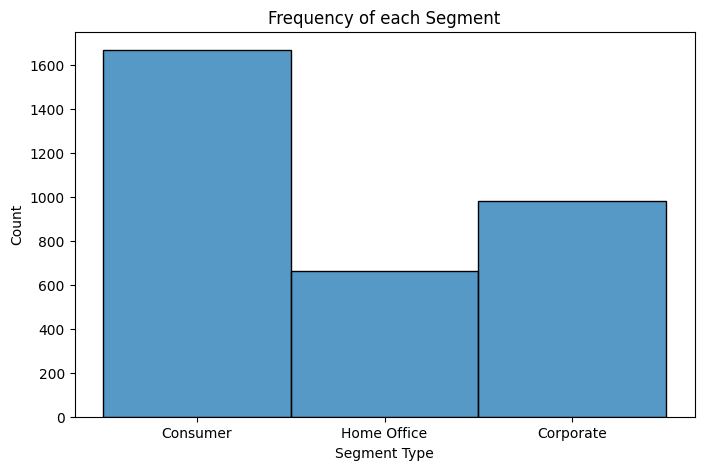

In [124]:
plt.figure(figsize=(8,5))
sns.histplot(ecommerce['Segment'], bins=10)
plt.title("Frequency of each Segment")
plt.xlabel("Segment Type")
plt.ylabel("Count")
plt.show()

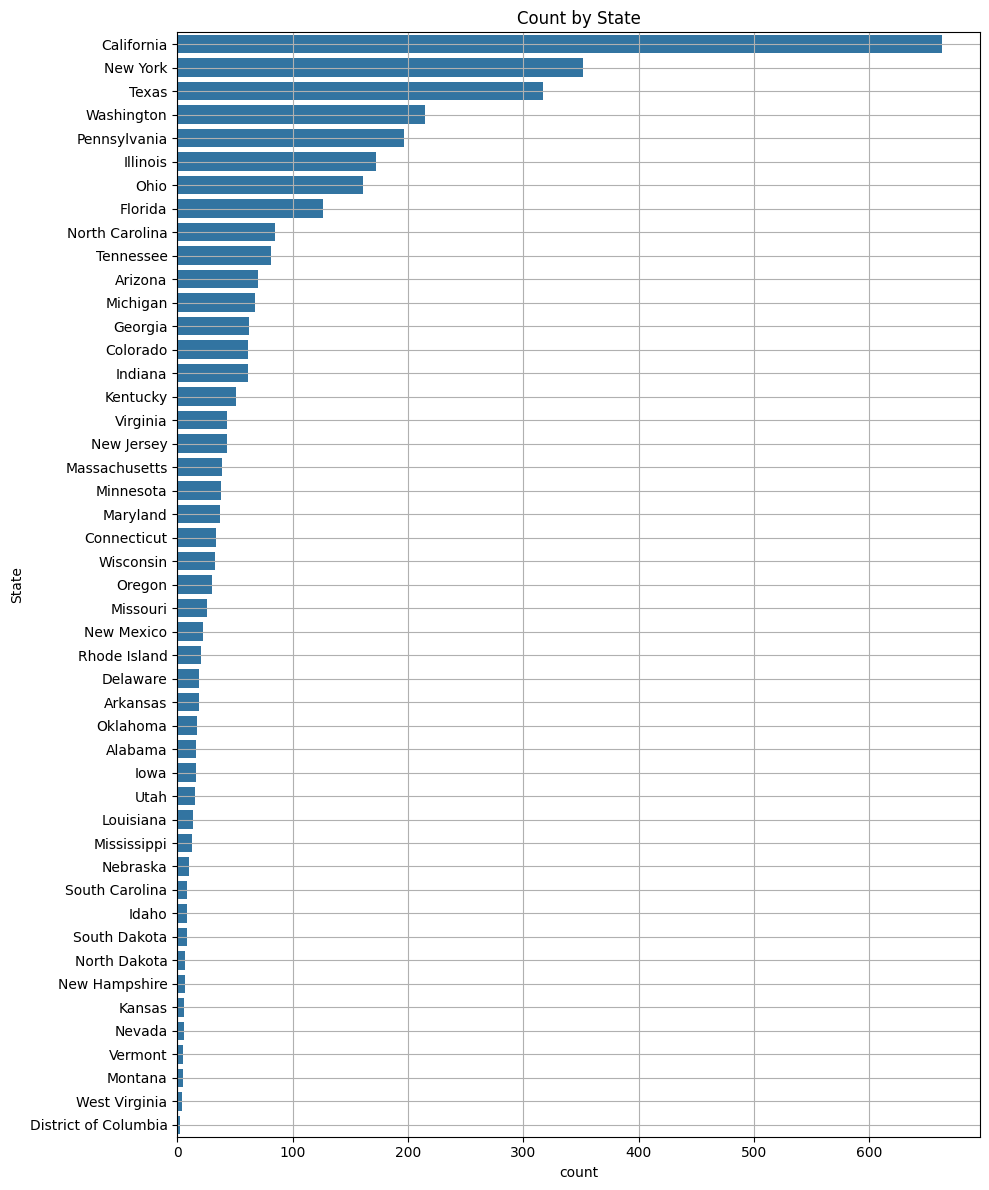

In [125]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,12)) 
sns.countplot(y='State', data=ecommerce, order=ecommerce['State'].value_counts().index)

plt.title("Count by State")
plt.grid(True)
plt.tight_layout()
plt.show()

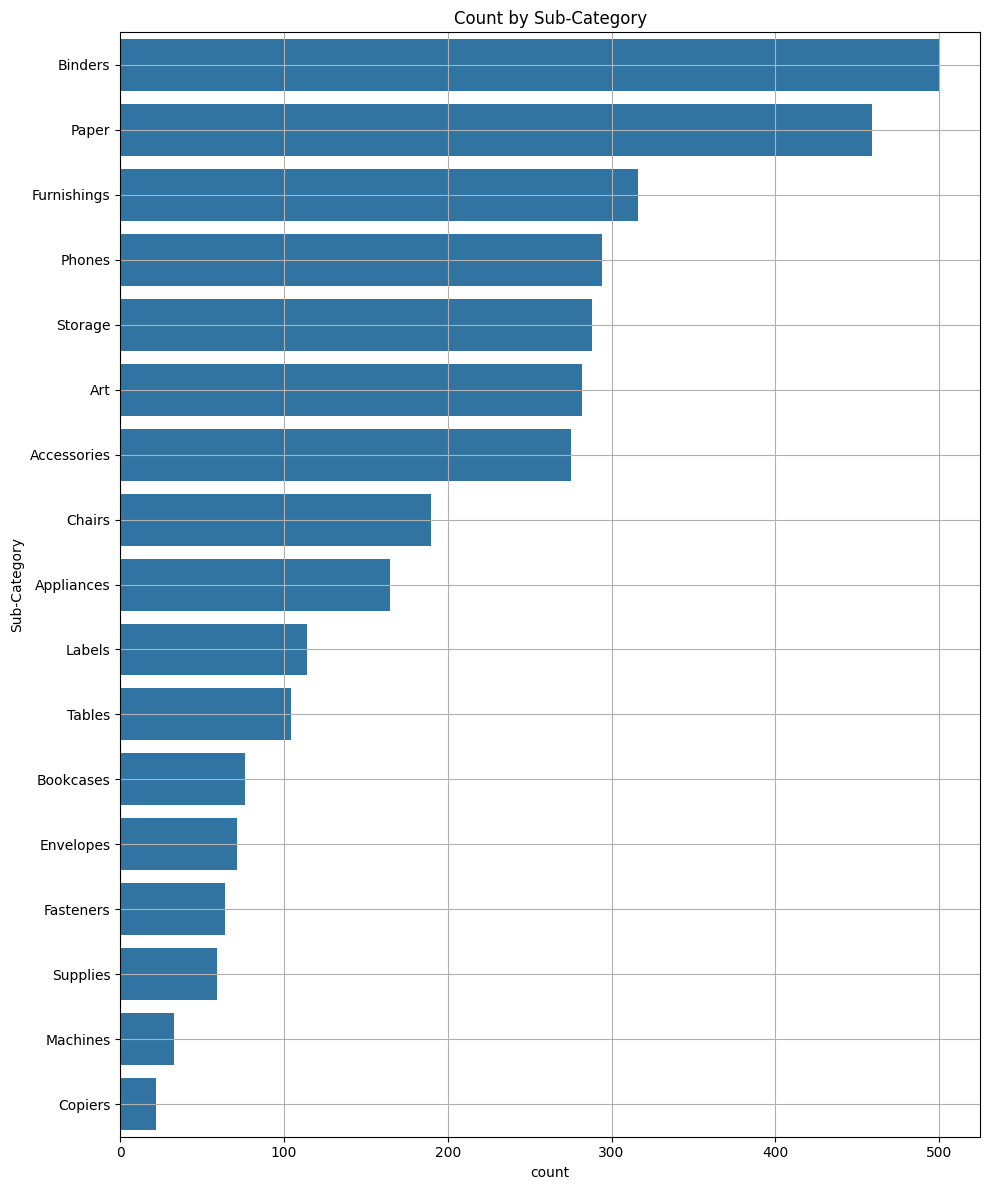

In [126]:
plt.figure(figsize=(10,12)) 
sns.countplot(y='Sub-Category', data=ecommerce, order=ecommerce['Sub-Category'].value_counts().index)

plt.title("Count by Sub-Category")
plt.grid(True)
plt.tight_layout()
plt.show()

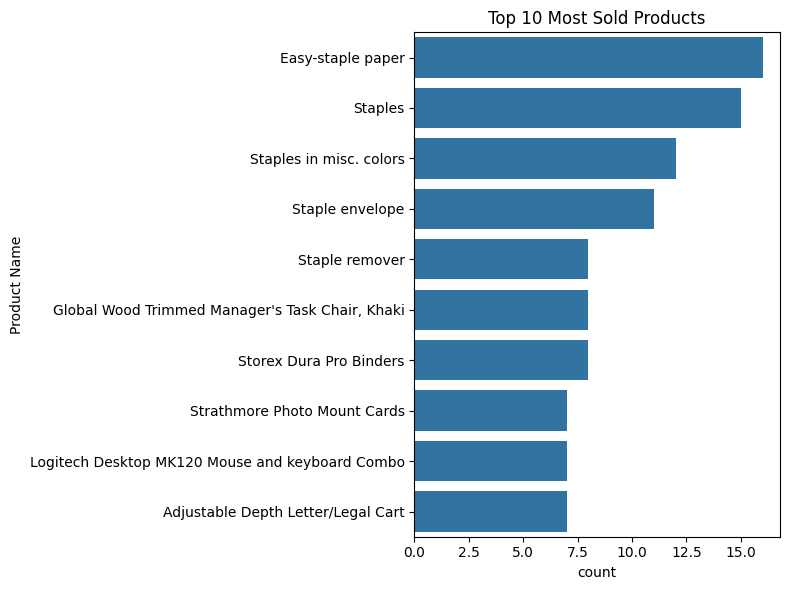

In [127]:
top_n = 10
top_products = ecommerce['Product Name'].value_counts().nlargest(top_n).index

plt.figure(figsize=(8,6))
sns.countplot(
    y='Product Name',
    data=ecommerce,
    order=top_products
)

plt.title(f"Top {top_n} Most Sold Products")
plt.tight_layout()
plt.show()

The histograms generated above convey clearly where there is higher frequency and are an appropriate visual for this dataset to effectively summarizes continuous numerical data by grouping values into ranges and showing the frequency of each range. This makes it easy to see the overall distribution, including where most sales or profits are concentrated, which parts of the country marketing resources should be allocated, which products perform best, whether the data are skewed, and if there are any outliers. This visual clarity helps businesses make informed decisions, identify opportunities, and detect potential risks in their sales and profit performance.

Based on the histograms above, most customers are based in California and are consumers likely buying for personal reasons, with office supplies, namely binders and paper being the most frequently purchased items. 

# 4. Storytelling With Data graph

Reproduce any graph of your choice in p. 52-68 of the Storytelling With Data book as best you can.  (The second half of chapter two).  You do not have to get the exact data values right, just the overall look and feel.

The graph I chose is on page 59.

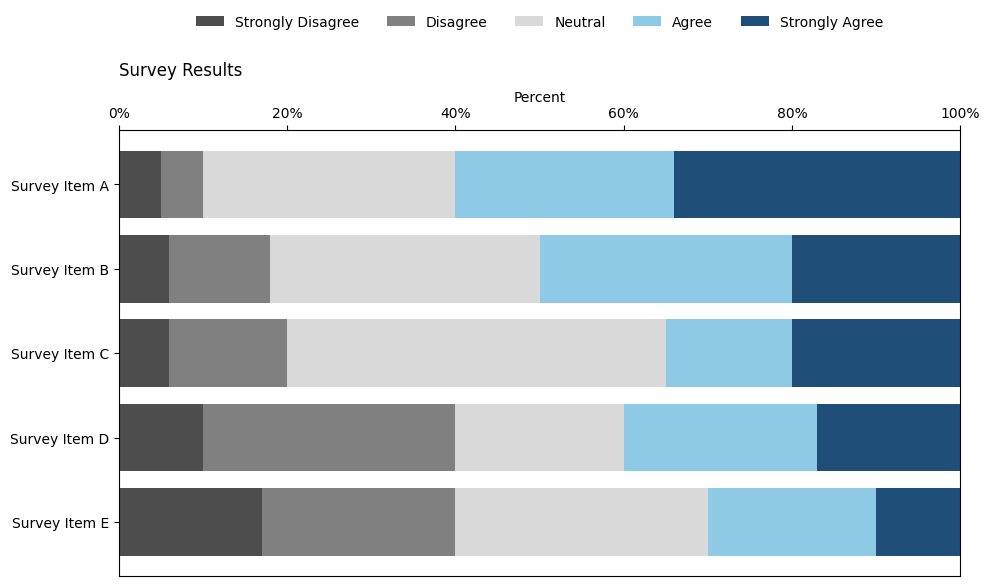

In [128]:
items = [
    "Survey Item A",
    "Survey Item B",
    "Survey Item C",
    "Survey Item D",
    "Survey Item E"
]

data = {
    "Strongly Disagree": [5, 6, 6, 10, 17],
    "Disagree": [5, 12, 14, 30, 23],
    "Neutral": [30, 32, 45, 20, 30],
    "Agree": [26, 30, 15, 23, 20],
    "Strongly Agree": [34, 20, 20, 17, 10]
}

colors = {
    "Strongly Disagree": "#4d4d4d",  
    "Disagree": "#808080",           
    "Neutral": "#d9d9d9",            
    "Agree": "#8ecae6",              
    "Strongly Agree": "#1f4e79"      
}


fig, ax = plt.subplots(figsize=(10, 6))

left = np.zeros(len(items))

for category in data:
    values = data[category]
    ax.barh(items, values, left=left, color=colors[category], label=category)
    left += np.array(values)
    
ax.set_xlim(0, 100)
ax.set_xticks(np.arange(0, 101, 20))
ax.set_xticklabels([f"{i}%" for i in range(0, 101, 20)])

ax.xaxis.set_ticks_position('top')
ax.xaxis.set_label_position('top')
ax.set_xlabel("Percent")

ax.invert_yaxis()

ax.set_title("Survey Results", loc="left", pad=40)

ax.legend(loc="lower center", bbox_to_anchor=(0.5, 1.20), ncol=5, frameon=False)

plt.tight_layout()
plt.show()